In [6]:
import pandas as pd
import numpy as np
from scipy.stats import skew

df = pd.read_csv("daily_sentiment_volatility.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

num_cols = ["sentiment_mean", "sentiment_volatility", "tweet_volume"]

summary_rows = []

for col in num_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_mask = (s < lower) | (s > upper)

    summary_rows.append({
        "variable": col,
        "n": s.shape[0],
        "mean": s.mean(),
        "median": s.median(),
        "std": s.std(),
        "min": s.min(),
        "max": s.max(),
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "skewness": skew(s, bias=False),
        "lower_bound": lower,
        "upper_bound": upper,
        "outliers_n": outlier_mask.sum(),
        "outliers_pct": outlier_mask.mean() * 100
    })


In [7]:
summary_df = pd.DataFrame(summary_rows)
print(summary_df)
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[col + "_outlier"] = ((df[col] < lower) | (df[col] > upper)).astype(int)

print(df.head())

               variable    n          mean        median           std  \
0        sentiment_mean  897  5.395116e-02  5.448443e-02  1.050251e-02   
1  sentiment_volatility  897  2.607521e-01  2.598003e-01  9.413643e-03   
2          tweet_volume  897  2.308659e+06  2.357783e+06  1.063241e+06   

             min           max            q1            q3           iqr  \
0      -0.018960  9.139171e-02  4.811878e-02  6.047118e-02  1.235240e-02   
1       0.235591  3.247512e-01  2.546768e-01  2.652824e-01  1.060561e-02   
2  288277.000000  4.774322e+06  1.351595e+06  3.193236e+06  1.841641e+06   

   skewness   lower_bound   upper_bound  outliers_n  outliers_pct  
0 -0.677022  2.959018e-02  7.899979e-02          22      2.452620  
1  1.149335  2.387683e-01  2.811908e-01          35      3.901895  
2 -0.128888 -1.410866e+06  5.955698e+06           0      0.000000  
        date  sentiment_mean  sentiment_volatility  tweet_volume  \
0 2020-03-19       -0.006166              0.294317        

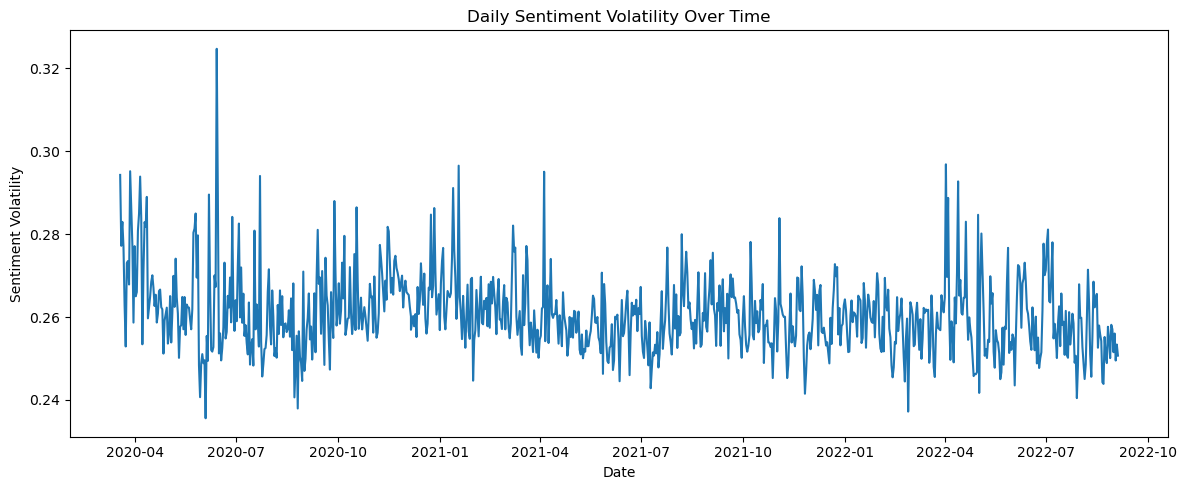

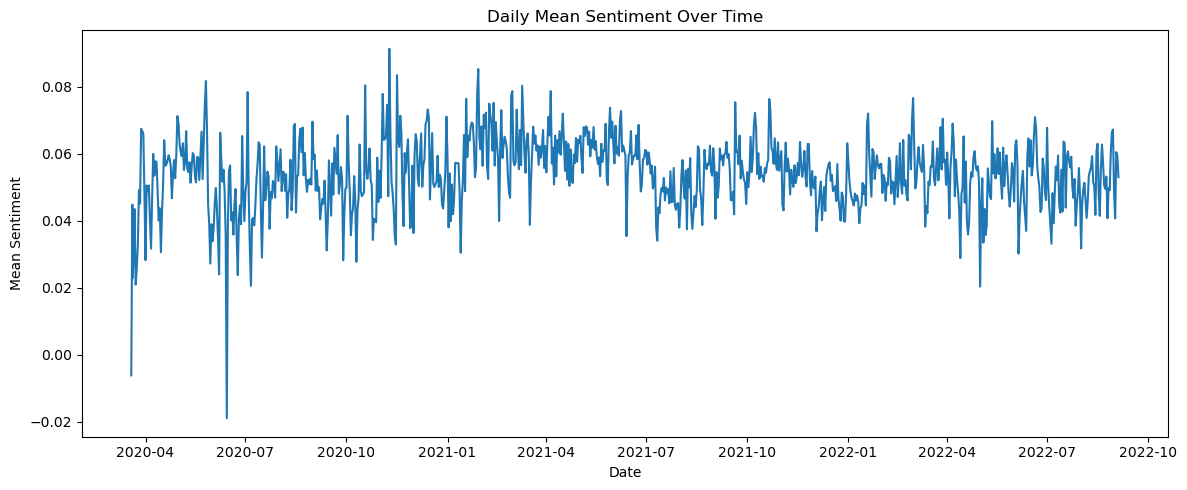

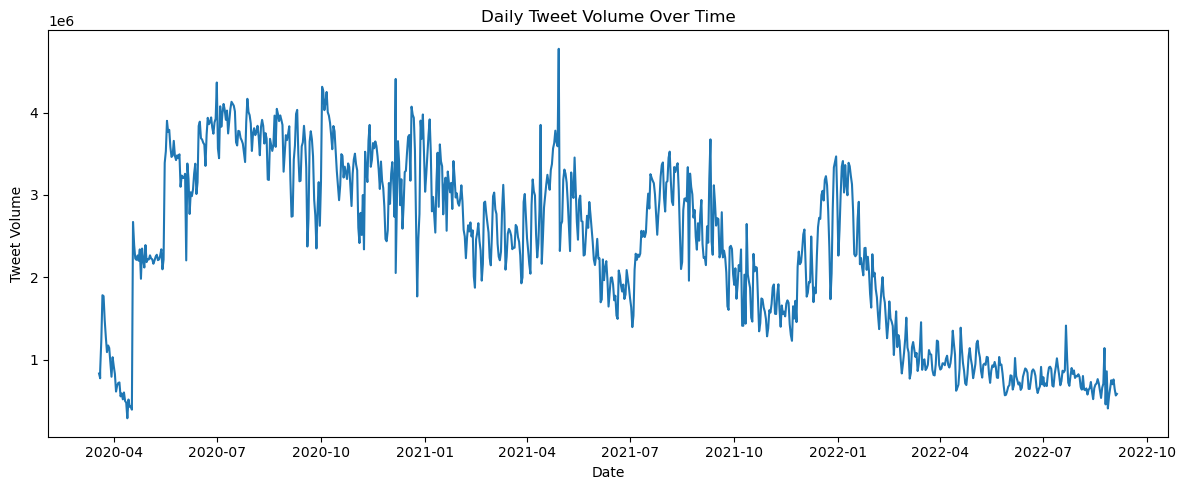

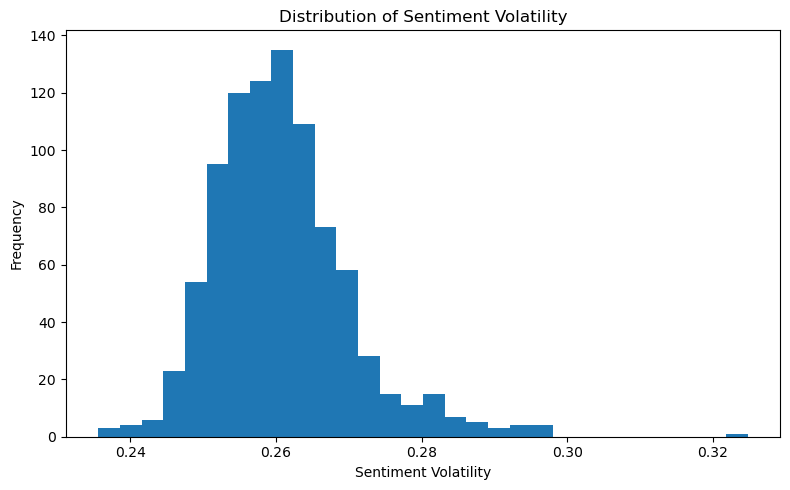

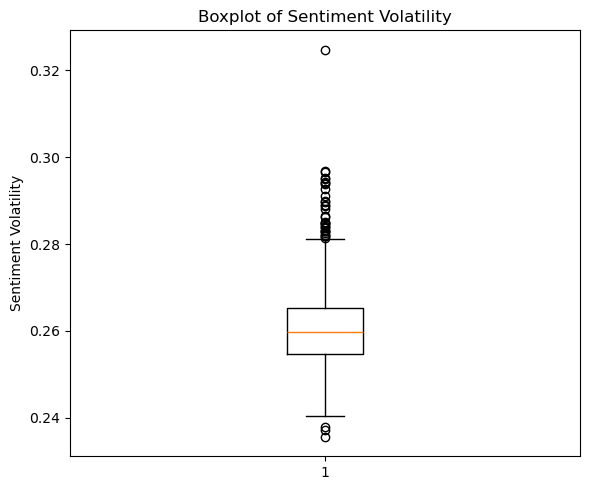

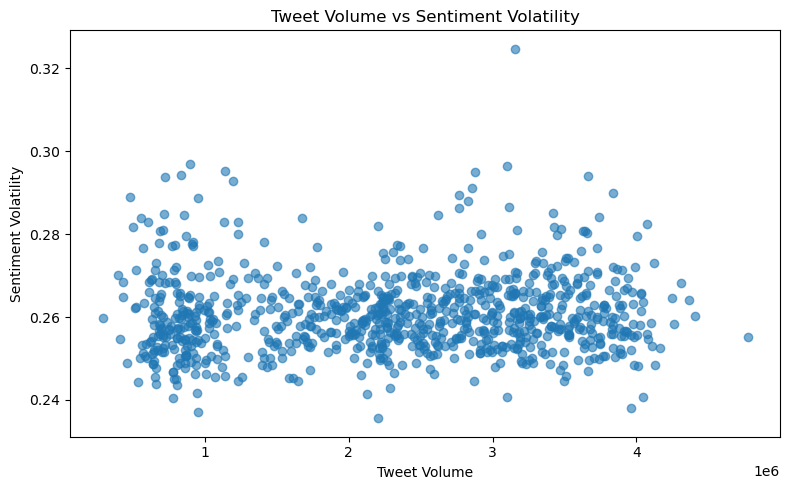

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["sentiment_volatility"])
plt.title("Daily Sentiment Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Sentiment Volatility")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["sentiment_mean"])
plt.title("Daily Mean Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Mean Sentiment")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["tweet_volume"])
plt.title("Daily Tweet Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Tweet Volume")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.hist(df["sentiment_volatility"], bins=30)
plt.title("Distribution of Sentiment Volatility")
plt.xlabel("Sentiment Volatility")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 5))
plt.boxplot(df["sentiment_volatility"].dropna())
plt.title("Boxplot of Sentiment Volatility")
plt.ylabel("Sentiment Volatility")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.scatter(df["tweet_volume"], df["sentiment_volatility"], alpha=0.6)
plt.title("Tweet Volume vs Sentiment Volatility")
plt.xlabel("Tweet Volume")
plt.ylabel("Sentiment Volatility")
plt.tight_layout()
plt.show()

In [10]:
df["date"] = pd.to_datetime(df["date"])

df_daily = df.groupby("date", as_index=False).agg({
    "sentiment_mean": "mean",
    "sentiment_volatility": "mean",
    "tweet_volume": "sum"
})
